# **Блок 1 – «Базовый». Анализ данных**

## **Задание 1: Анализ таблиц**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = 'https://raw.githubusercontent.com/datasets/s-and-p-500-companies-financials/main/data/constituents-financials.csv'
file='constituents-financials_csv.csv'
data = pd.read_csv(url, sep=',') # загрузка таблицы по ссылке

data.head()  # вывод первых пяти строк таблицы

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,138721055226,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,10783419933,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,102121042306,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,181386347059,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,98765855553,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [ ]:
data.shape  # кол-во строк и столбцов

(505, 14)

In [ ]:
data.dtypes # типы данных столбцов

Symbol             object
Name               object
Sector             object
Price             float64
Price/Earnings    float64
Dividend Yield    float64
Earnings/Share    float64
52 Week Low       float64
52 Week High      float64
Market Cap          int64
EBITDA            float64
Price/Sales       float64
Price/Book        float64
SEC Filings        object
dtype: object

In [ ]:
# Посчитайте количество строк с записями для из отрасли Industrials (столбец Sector).
sum(data['Sector']=='Industrials')

67

In [ ]:
# Сгруппируйте таблицу по значениям столбца Sector, посчитайте количество строк, оказавшихся в каждой группе.

group=data.groupby('Sector')
group.size()

Sector
Consumer Discretionary        84
Consumer Staples              34
Energy                        32
Financials                    68
Health Care                   61
Industrials                   67
Information Technology        70
Materials                     25
Real Estate                   33
Telecommunication Services     3
Utilities                     28
dtype: int64

In [ ]:
# Найдите и посчитайте количество строк, содержащих пропущенные значения.
data.isna().sum()

Symbol            0
Name              0
Sector            0
Price             0
Price/Earnings    2
Dividend Yield    0
Earnings/Share    0
52 Week Low       0
52 Week High      0
Market Cap        0
EBITDA            0
Price/Sales       0
Price/Book        8
SEC Filings       0
dtype: int64

In [ ]:
# Проверьте, есть ли в группе хоть одна фирма с аббревиатурой (столбец Symbol), начинающейся на букву "А".
group.apply(lambda x: any(x['Symbol'].str.startswith('A')))

Sector
Consumer Discretionary         True
Consumer Staples               True
Energy                         True
Financials                     True
Health Care                    True
Industrials                    True
Information Technology         True
Materials                      True
Real Estate                    True
Telecommunication Services    False
Utilities                      True
dtype: bool

In [ ]:
# Посчитайте и запишите как столбец разницу максимального и минимального значений из столбца Price для каждой группы.
# Отобразите результат в виде столбчатого графика, настройте график, подпишите оси, легенду графика, название графика.
# Отобразите медианное значение линией красного цвета.

In [ ]:
result = group.Price.agg([lambda x: x.max() - x.min(), 'mean'])
result.columns = ['Range', 'Median']
result

,Range,Median
Sector,,
Consumer Discretionary,1795.63,124.034524
Consumer Staples,188.77,79.764118
Energy,166.34,57.887500
Financials,496.00,89.056029
Health Care,575.80,132.515738
Industrials,319.85,116.887612
Information Technology,996.49,119.242857
Materials,370.49,102.386800
Real Estate,395.97,88.712727


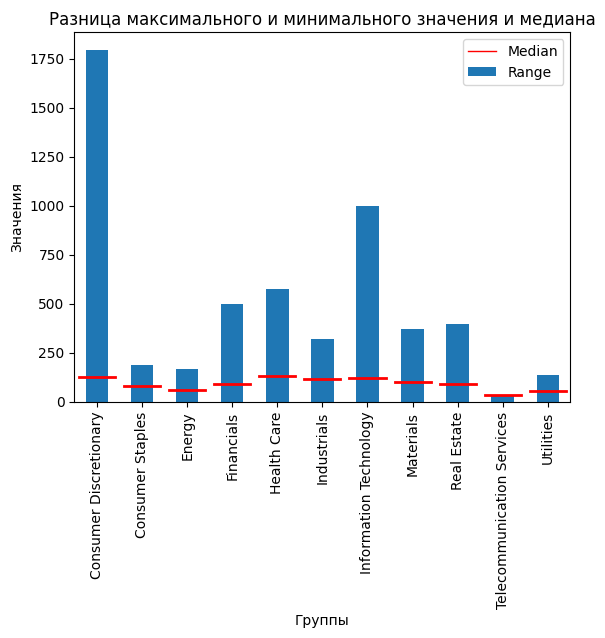

In [ ]:
fig, ax = plt.subplots()

# Построение столбцов для Range и Median
result[['Range']].plot(kind='bar', ax=ax)

# Добавление красной линии для медианы
ax.plot([0, 0], [0, 0], color='red', linewidth=1, label='Median')
for i, median in enumerate(result['Median']):
    ax.plot([i - 0.4, i + 0.4], [median, median], color='red', linewidth=2)

# Настройка меток осей
ax.set_xlabel('Группы')
ax.set_ylabel('Значения')
ax.set_title('Разница максимального и минимального значения и медиана')
plt.legend()
plt.show()

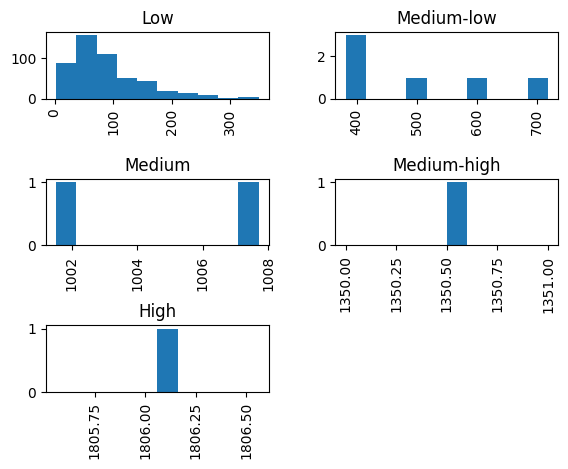

In [ ]:
# Разбейте столбец Price на 5 интервалов.

price_labels = ['Low', 'Medium-low', 'Medium', 'Medium-high', 'High']
price_categories = pd.cut(data['Price'], 5, labels=price_labels)

data['Price'].hist(by=price_categories)
plt.subplots_adjust(hspace = 1.2)
plt.show()

In [ ]:
# Выведите на экран название (Name) фирмы, у которой цена (Price) входит в интервал Exclusive.

exclusive = 'High'
high_firms = data[price_categories == exclusive]['Name'].tolist()
print(high_firms)

['Priceline.com Inc']


## **Задание 2: Анализ изображений**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import requests
import sys
import random

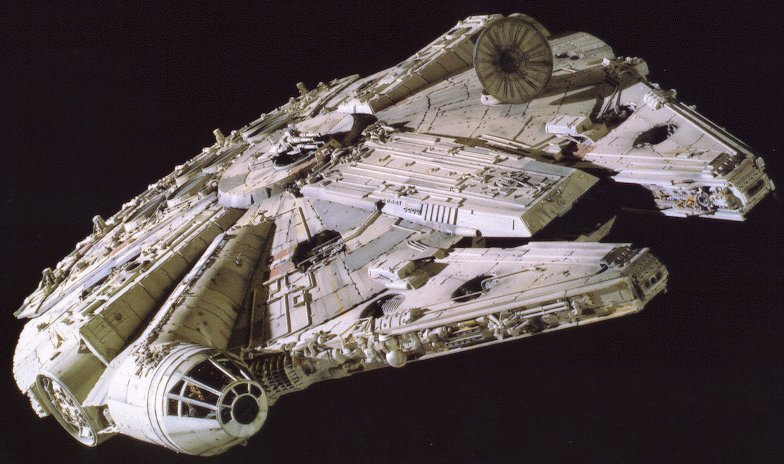

In [ ]:
url = 'https://upload.wikimedia.org/wikipedia/ru/d/dc/Melfal.jpg'
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
try:
    resp = requests.get(url, stream=True,headers=headers).raw
except requests.exceptions.RequestException as e:  #
    sys.exit(1)

try:
    img = Image.open(resp)
except IOError:
    print("Unable to open image")
    sys.exit(1)

img.save('downloaded_img.jpg', 'jpeg')
img

In [ ]:
# узнать размер изображения;
width, height = img.size # размер изображения
print(width, height)

784 464


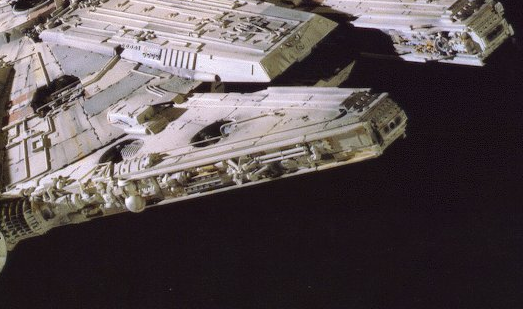

In [ ]:
# обрезать изображение на 1/3 по центру;
box = (img.width / 3, img.height / 3, img.width, img.height)
img2 = img.crop(box)
img2.save('image_cropped.jpg')
img2

(784, 464)
(100, 100)


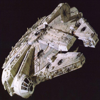

In [ ]:
# масштабировать изображение к размеру 100*100 с и без сохранения соотношения сторон.
img = Image.open('downloaded_img.jpg')
print(img.size)
img = img.resize((100, 100))
print(img.size)
img

In [ ]:
# Повторите процесс, используя 3 разных фильтра (на ваш выбор);

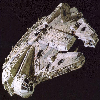

In [ ]:
img = Image.open('downloaded_img.jpg')
img = img.resize((100, 100), Image.NEAREST)
img

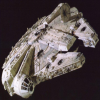

In [ ]:
img = Image.open('downloaded_img.jpg')
img = img.resize((100, 100), Image.HAMMING)
img

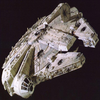

In [ ]:

img = img.resize((100, 100), Image.LANCZOS)
img

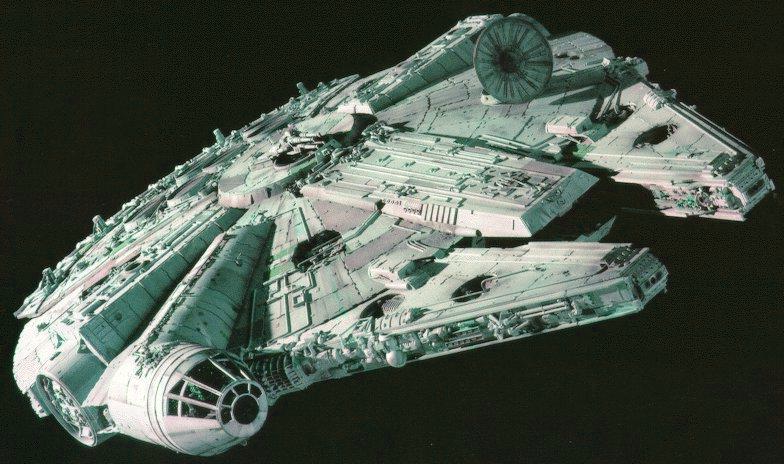

In [ ]:
# разделите изображение на цветовые каналы, перемешайте порядок каналов случайным образом,
# соберите обратно цветное изображение, выведите на экран;
img = Image.open('downloaded_img.jpg')
r, g, b = img.split() # разделим изображение на цветовые каналы
channels = [r, g, b]
random.shuffle(channels) # перемешаем порядок каналов
img = Image.merge("RGB", channels) # соберем обратно цветное изображение
img

<ipython-input-31-44b00b3aae6f>:13: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = idraw.textsize(text, font=font)


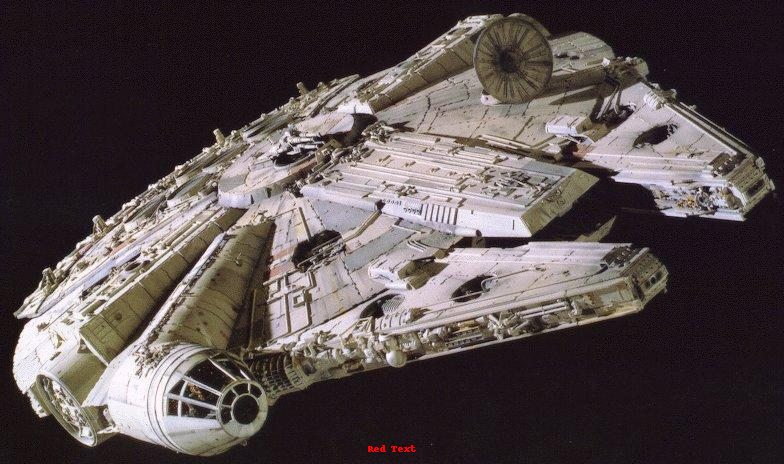

In [ ]:
# поверх изображения наложите текст размером 14, красным цветом, выравнивание по центру.
# Текст расположен снизу и не выходит за рамки изображения;
from PIL import Image, ImageDraw, ImageFont

font = ImageFont.load_default()
img = Image.open('downloaded_img.jpg')
text = "Red Text"
font_color = (255, 0, 0)  # Красный цвет
idraw = ImageDraw.Draw(img)

# Определение размеров изображения и текста
image_width, image_height = img.size
text_width, text_height = idraw.textsize(text, font=font)

# Определение позиции текста (внизу по центру)
x_position = (image_width - text_width) / 2
y_position = image_height - text_height - 10  # 10 пикселей отступ от нижнего края

# Наложение текста на изображение
idraw.text((x_position, y_position), text, font=font, fill=font_color)
img

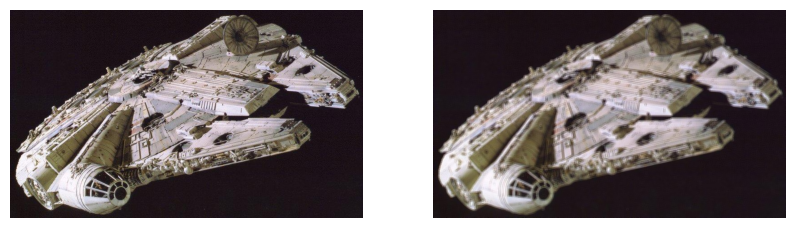

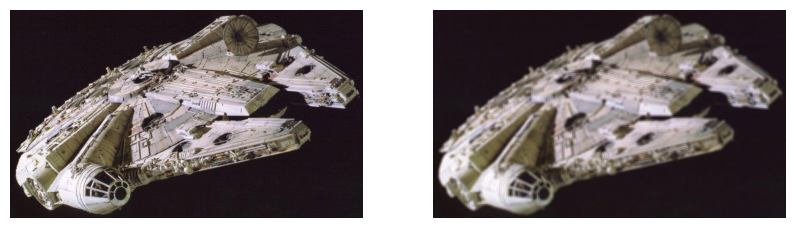

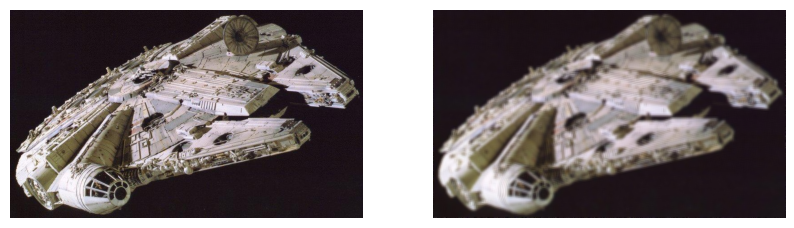

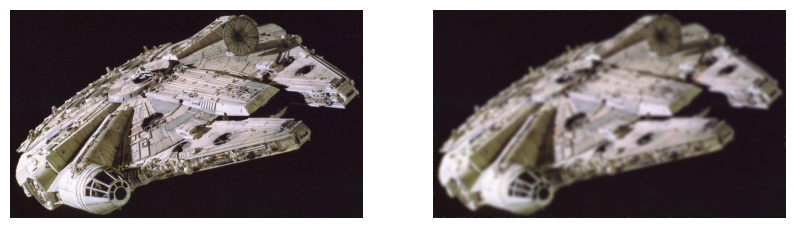

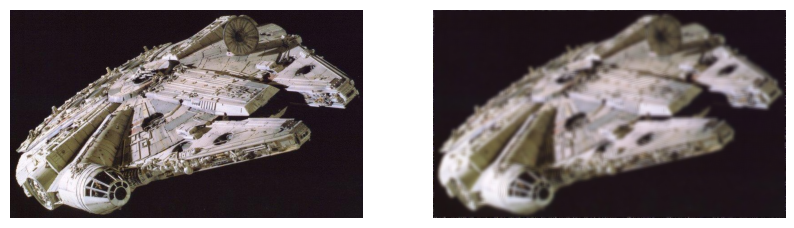

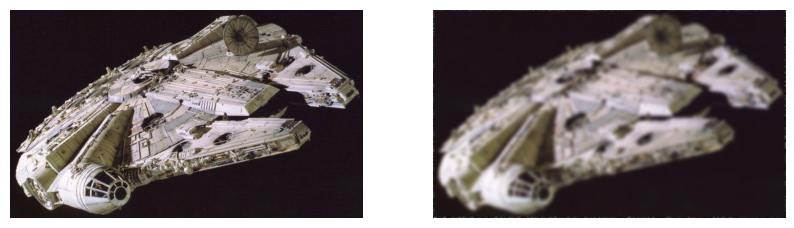

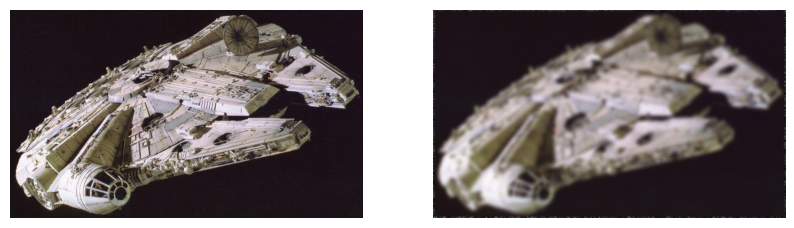

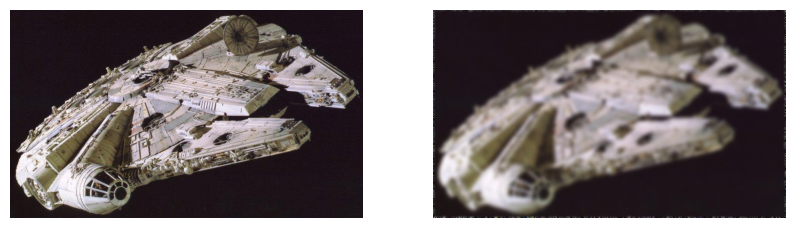

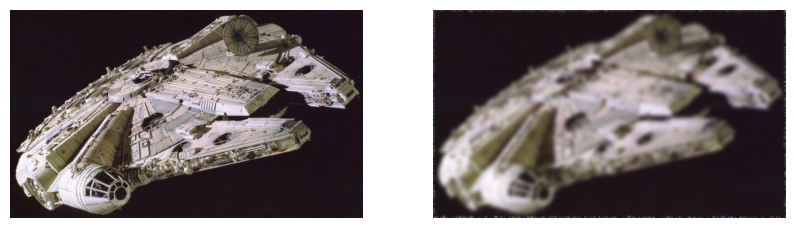

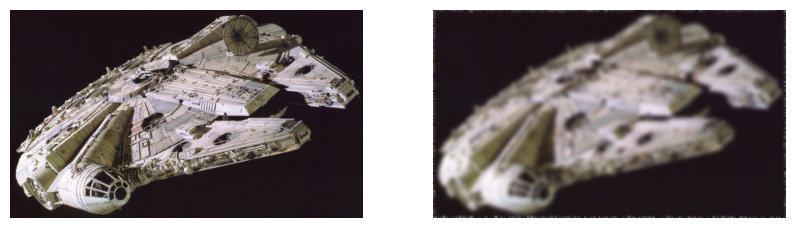

In [ ]:
# примените последовательно фильтр размытия (любой), фильтр повышения резкости.
# Повторите процесс несколько раз (в цикле), выведите рядом исходное изображение и результат каждой итерации цикла;
from PIL import ImageFilter
img = Image.open('downloaded_img.jpg')
iterations = 10
restored_img = []

blurred = img.filter(ImageFilter.BLUR)
sharped = blurred.filter(ImageFilter.SHARPEN)

for i in range(iterations):
  restored_img.append(sharped)
  blurred = sharped.filter(ImageFilter.BLUR)
  sharped = blurred.filter(ImageFilter.SHARPEN)

for i in range(iterations):
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(img)
  axes[0].axis('off')

  axes[1].imshow(restored_img[i])
  axes[1].axis('off')
  plt.show()
  print()

Число черных (контурных) пикселей = 38084


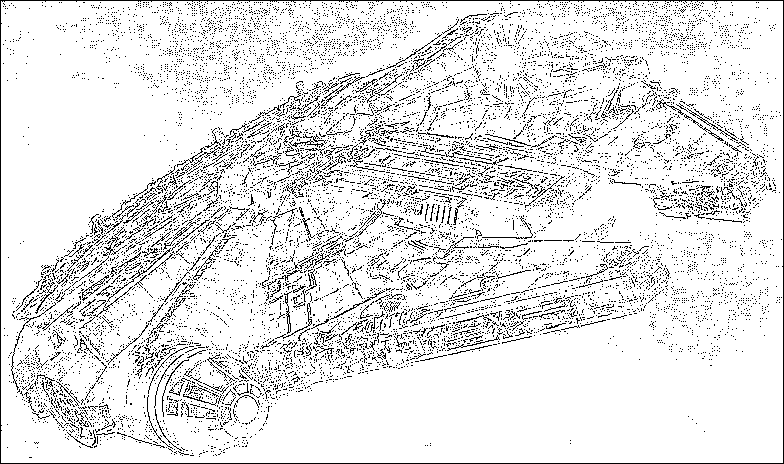

In [ ]:
#	выделите на изображении его контур, переведите результат в черно-белое представление,
# посчитайте число черных (контурных) пикселей.

image = Image.open('downloaded_img.jpg')
gray_image = image.convert('L') # преобразование изображения в оттенки серого

edges = gray_image.filter(ImageFilter.CONTOUR) # фильтр для выделения контуров

bw_image = edges.point(lambda x: 0 if x < 128 else 255, '1') # преобразование изображения в черно-белое

bw_array = np.array(bw_image)  # подсчет кол-во черных пикселей
num_black_pixels = np.sum(bw_array == 0)
print('Число черных (контурных) пикселей =', num_black_pixels)
bw_image

## **Задание 3: Визуализация многомерных данных**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from PIL import Image, ImageDraw

(1797, 64)


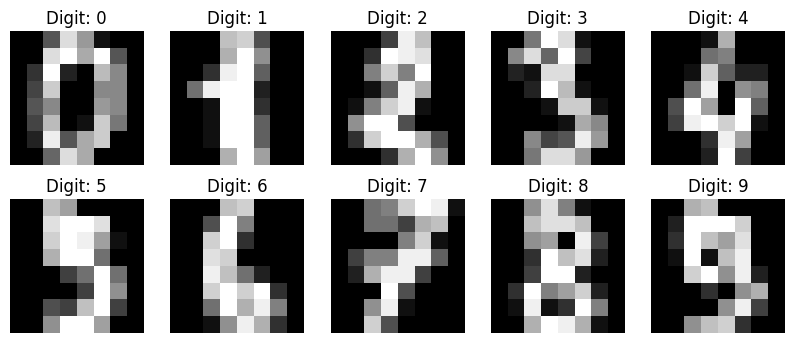

In [ ]:
# Загрузите набор данных о рукописных цифрах MNIST из sklearn.
digits = load_digits()
X = digits.data
y = digits.target

# Изображения цифр представьте как 64-мерный вектор.
print(X.shape)
# Вывод первых 10 цифр
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis('off')

plt.show()


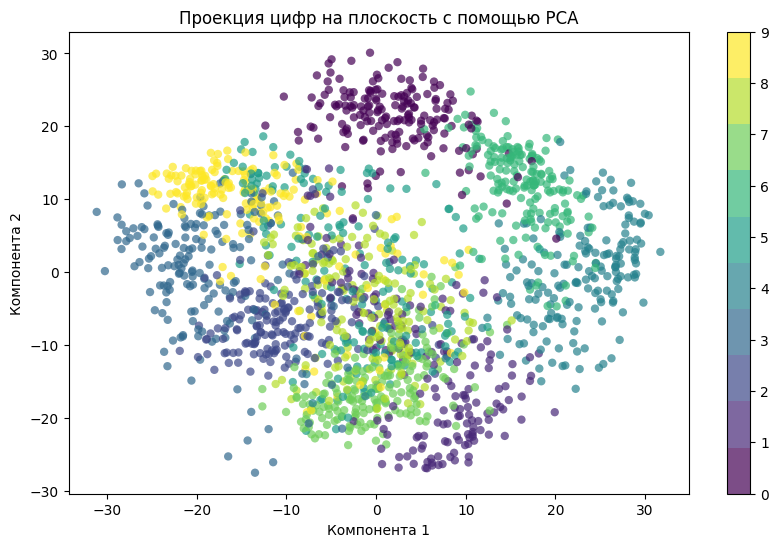

In [ ]:
# Методом главных компонент спроецируйте эти вектора на плоскость, оставьте только две главные компоненты
# Отобразите на плоскости цифры, располагая их по координатам, соответствующим выделенным компонентам.
# Настройте масштаб так, чтобы не загромождать рисунок.

pca = PCA(n_components=2) # Применение PCA для уменьшения размерности до 2
projected = pca.fit_transform(digits.data)

plt.figure(figsize=(10, 6))
plt.scatter(projected[:, 0], projected[:, 1], c=digits.target, edgecolor='none', alpha=0.7, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.colorbar()
plt.title('Проекция цифр на плоскость с помощью PCA')
plt.show()

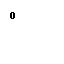

In [ ]:
# Нарисуйте самостоятельно цифру, сохраните ее изображение в файл, загрузите файл,
# отмасштабируйте размер к тому же, что и в MNIST. Отобразите эту цифру на том же графике, пометьте добавленную цифру жирным.


# Создание изображения цифры 0
img = Image.new('L', (64, 64), color=255)  # 'L' для режима grayscale
draw = ImageDraw.Draw(img)
draw.text((10, 10), '0', fill=0)
img.save('digit.png')
img

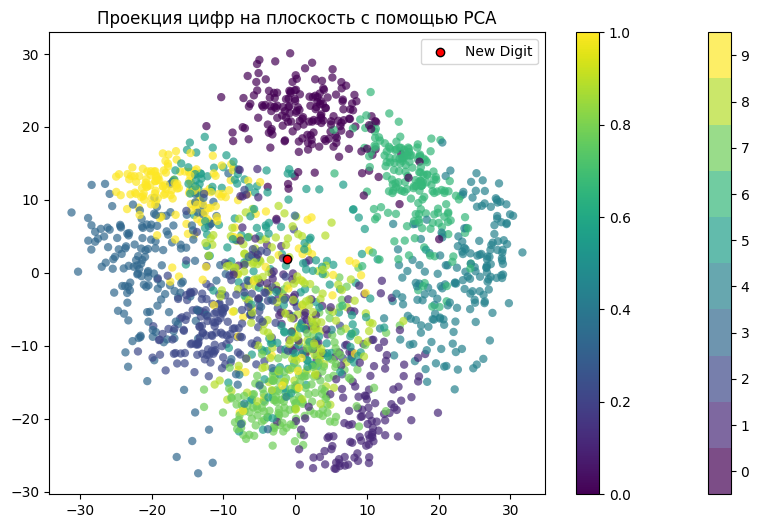

In [ ]:
img_resized = img.resize((8, 8), Image.ANTIALIAS)
# Преобразование изображения в массив numpy
digit_data = np.array(img_resized)
# Инвертирование цветов
digit_data = 255 - digit_data
# Масштабирование данных как в load_digits
digit_data = digit_data / 16.0

# Преобразование новой цифры с помощью PCA
new_digit_flat = digit_data.flatten().reshape(1, -1)
new_digit_pca = pca.transform(new_digit_flat)

# Отображение проекций
plt.figure(figsize=(10, 6))
scatter = plt.scatter(projected[:, 0], projected[:, 1], c=digits.target, edgecolor='none', alpha=0.7, cmap=plt.cm.get_cmap('viridis', 10))

# Добавление новой цифры на график
plt.scatter(new_digit_pca[:, 0], new_digit_pca[:, 1], c='red', edgecolor='black', label='New Digit')

cbar = plt.colorbar(scatter, boundaries=np.arange(11) - 0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))

plt.colorbar()
plt.legend()
plt.title('Проекция цифр на плоскость с помощью PCA')
plt.show()

# **Блок 2 – «Продвинутый». Базовые модели машинного обучения для анализа данных**

## **Задание 1: Логистическая регрессия**

**Задание:**
Загрузите набор данных о рукописных цифрах MNIST из sklearn.

Изображения цифр представьте как 64-мерный вектор.

1)	Создайте модель логистической регрессии для распознавания этих цифр.

2)	Разделите данные на обучающую и тестовую часть, оставив на тест 30%
данных.

3)	Обучите модель. Подбирайте гиперпараметры с целью повышения качества обучения, но время обучения не должно превышать 5 минут.

4)	Посчитайте ошибки на тесте: матрицу потерь, точность (accuracy), полноту (recall) и F1 меру.

Методом главных компонент спроецируйте 64-мерные вектора на меньшее пространство N. Повторите пункты 1)-4) для спроецированных векторов.

Сравните на тесте качество обучения для N=2, 5, 10, 20, 30, 40, 50, 60
Также сравните время, необходимое для обучения.

Используйте одинаковые гиперпараметры для обучения.

Результаты сравнения запишите в таблицу pandas и сохраните на диск в csv файл.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import time
import pandas as pd

(1797, 64)


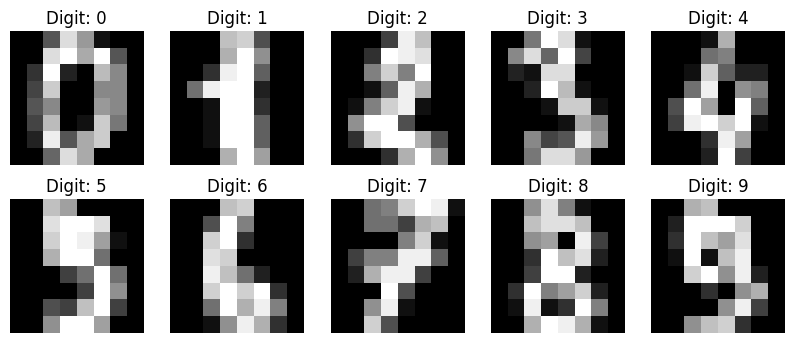

In [ ]:
# Загрузите набор данных о рукописных цифрах MNIST из sklearn.
digits = load_digits()
X = digits.data
y = digits.target

# Изображения цифр представьте как 64-мерный вектор.
print(X.shape)
# Вывод первых 10 цифр
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis('off')

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # разделение данных
logistic_model = LogisticRegression(max_iter=10000, n_jobs=-1, random_state=42) # создание модели

logistic_model.fit(X_train, y_train) # обучение модели

y_pred = logistic_model.predict(X_test) # предсказания на тестовой выборке

In [ ]:
# вычисление метрик
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 мера:", f1)


Confusion Matrix:
 [[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  1  0  0  0  0  0  2  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 52  0  1  0  0  0  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  1  0  0  0 63  1  0  0  1]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  1  0 54  0  0]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  1  0  0  0  0  2 56]]
Accuracy: 0.9722222222222222
Recall: 0.9729688736551022
F1 мера: 0.9720884522335643


In [ ]:
def calculate_pca_logistic(n_components, X_train, X_test, y_train, y_test):
    # Применение PCA и логистической регрессии
    pca = PCA(n_components=n_components)

    logistic_model = LogisticRegression(max_iter=10000, n_jobs=-1, random_state=42)
    pipeline = Pipeline(steps=[('pca', pca), ('logistic', logistic_model)])

    start_time = time.time()
    pipeline.fit(X_train, y_train) # обучение модели
    end_time = time.time()
    training_time = end_time - start_time

    y_pred = pipeline.predict(X_test) # предсказания на тестовой выборке
    # вычисление метрик
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    return conf_matrix, accuracy, recall, f1, training_time

results = pd.DataFrame({
    'N': [],
    'Accuracy': [],
    'Recall': [],
    'F1_Score': [],
    'Training_Time': []
})
N = [2, 5, 10, 20, 30, 40, 50, 60]
for i in N:
  conf_matrix, accuracy, recall, f1, train_time = calculate_pca_logistic(i, X_train, X_test, y_train, y_test)
  print(f'N = {i}:')
  print("Confusion Matrix:\n", conf_matrix)
  print("Accuracy:", accuracy)
  print("Recall:", recall)
  print("F1 мера:", f1)
  print("Train time:", train_time)
  print('--------------------------------')

  new_data = {
    'N': i,
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_Score': f1,
    'Training_Time': train_time
  }

  results = results._append(new_data, ignore_index=True)



N = 2:
Confusion Matrix:
 [[47  0  0  0  0  1  5  0  0  0]
 [ 1 27  0  0  3  2  0  3 12  2]
 [ 0  1 34  3  0  1  0  1  7  0]
 [ 0  0  5 39  0  2  0  1  0  7]
 [ 0  3  0  0 51  0  6  0  0  0]
 [ 2 10  5  0  0 10  3  8  9 19]
 [ 7  0  0  0  2  0 44  0  0  0]
 [ 0 10  6  0  0  1  0 34  4  0]
 [ 0  5  7  0  0  9  0  6 15  1]
 [ 0  1  4  6  0  3  1  3  1 40]]
Accuracy: 0.6314814814814815
Recall: 0.6349107890311053
F1 мера: 0.6196387752338575
Train time: 0.8296942710876465
--------------------------------
N = 5:
Confusion Matrix:
 [[53  0  0  0  0  0  0  0  0  0]
 [ 0 37  1  0  3  2  0  0  4  3]
 [ 0  0 38  1  0  0  0  0  8  0]
 [ 0  1  3 45  0  0  0  1  1  3]
 [ 0  2  0  0 56  0  0  1  1  0]
 [ 0  1  0  0  2 59  0  0  2  2]
 [ 3  0  0  0  0  0 49  0  1  0]
 [ 0  0  5  0  0  0  0 48  1  1]
 [ 1  2  4  3  0  1  0  1 29  2]
 [ 0  1  2  6  1  1  0  4  1 43]]
Accuracy: 0.8462962962962963
Recall: 0.8409604437491195
F1 мера: 0.8401256119357894
Train time: 1.6664834022521973
-----------------------

In [ ]:
results

,N,Accuracy,Recall,F1_Score,Training_Time
0,2.0,0.631481,0.634911,0.619639,0.314622
1,5.0,0.846296,0.840960,0.840126,0.485509
2,10.0,0.912963,0.910820,0.909155,0.751367
3,20.0,0.946296,0.948727,0.946950,0.752833
4,30.0,0.964815,0.963582,0.963462,0.551571
5,40.0,0.974074,0.974664,0.974045,0.444640
6,50.0,0.972222,0.972969,0.972088,0.449342
7,60.0,0.972222,0.972969,0.972088,0.449927


## **Задание 2: Кластеризация**

**Задание:** Сгенерируйте такие наборы данных. Проведите их кластеризацию методами:

1) К-средних

2) DBScan (любая модификация)

3) Gaussian mixtures

Гиперпараметры методов подбирайте с целью улучшения кластеризации. Посчитайте качество кластеризации Rand index.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import time

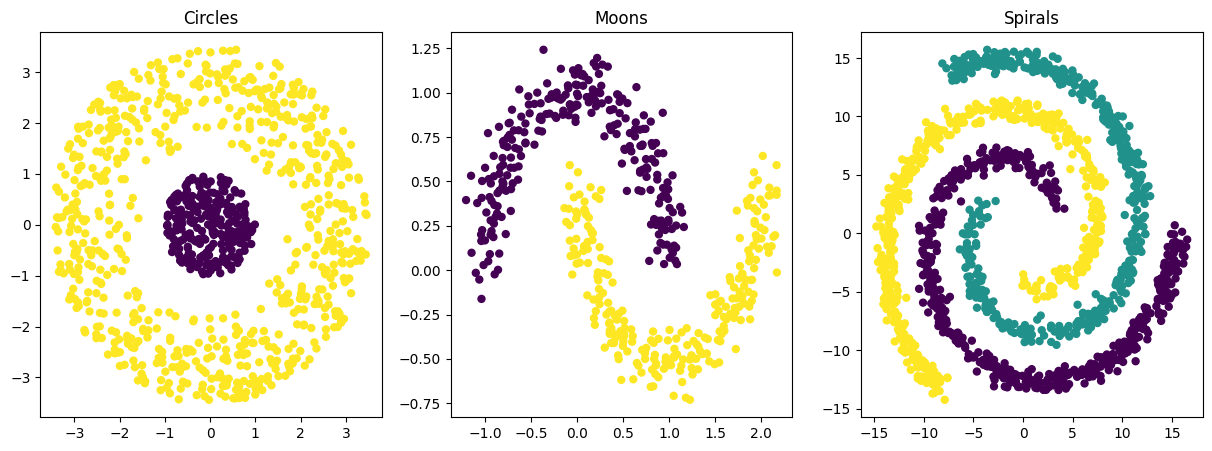

In [ ]:
def generate_circles(inner_radius=1, outer_radius=3, inner_points=250, outer_points=700, center=(0, 0)):
    theta_inner = np.random.rand(inner_points) * 2 * np.pi
    r_inner = np.sqrt(np.random.rand(inner_points)) * inner_radius
    x_inner = center[0] + r_inner * np.cos(theta_inner)
    y_inner = center[1] + r_inner * np.sin(theta_inner)
    inner_coords = np.column_stack((x_inner, y_inner))
    inner_labels = np.zeros(inner_points,)

    theta_outer = np.random.rand(outer_points) * 2 * np.pi
    r_outer = np.sqrt(np.random.rand(outer_points)) * (outer_radius - inner_radius) + inner_radius + 0.5
    x_outer = center[0] + r_outer * np.cos(theta_outer)
    y_outer = center[1] + r_outer * np.sin(theta_outer)
    outer_coords = np.column_stack((x_outer, y_outer))
    outer_labels = np.ones(outer_points,)

    labels = np.concatenate((inner_labels, outer_labels))
    dataset = np.vstack((inner_coords, outer_coords))
    return dataset, labels


def generate_moons(n_points=500, noise=0.1, shuffle=True):
    dataset, labels = make_moons(n_samples=n_points, shuffle=shuffle, noise=noise, random_state=42)
    return dataset, labels


def generate_spiral(n_points=500, n_spirals=3, noise=0.5, random_state=42):
    np.random.seed(random_state)
    theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi
    r_a = 2 * theta + np.pi  # Radius
    data = []
    labels = []
    for i in range(n_spirals):
        x = r_a * np.cos(theta + 2 * np.pi * i / n_spirals) + np.random.randn(n_points) * noise
        y = r_a * np.sin(theta + 2 * np.pi * i / n_spirals) + np.random.randn(n_points) * noise
        data.extend(np.array([x, y]).T)
        labels.extend([i] * n_points)
    data = np.array(data)
    labels = np.array(labels)
    return data, labels

# Создание датасетов
circles, circles_labels = generate_circles()
moons, moons_labels = generate_moons()
spiral, spiral_labels = generate_spiral()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(circles[:, 0], circles[:, 1], c=circles_labels, s=25)
plt.title('Circles')

plt.subplot(1, 3, 2)
plt.scatter(moons[:,0], moons[:,1], c=moons_labels, s=25)
plt.title('Moons')

plt.subplot(1, 3, 3)
plt.scatter(spiral[:, 0], spiral[:, 1], c=spiral_labels, s=25)
plt.title('Spirals')

plt.show()

Rand Index для K-means: -0.0024117864456513383


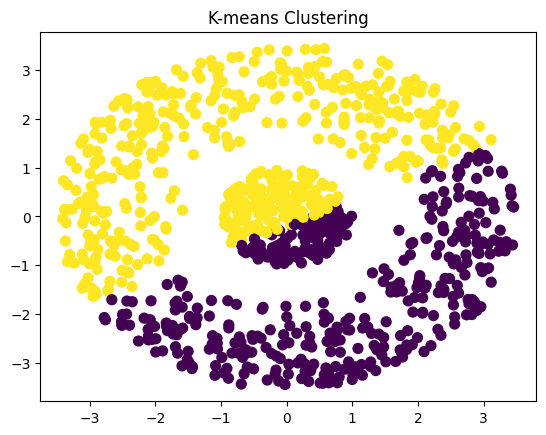

Rand Index для DBSCAN: 1.0


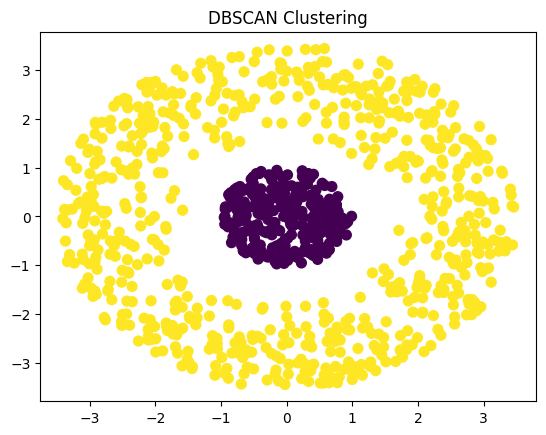

Rand Index для Gaussian Mixtures: -0.0041187497473634


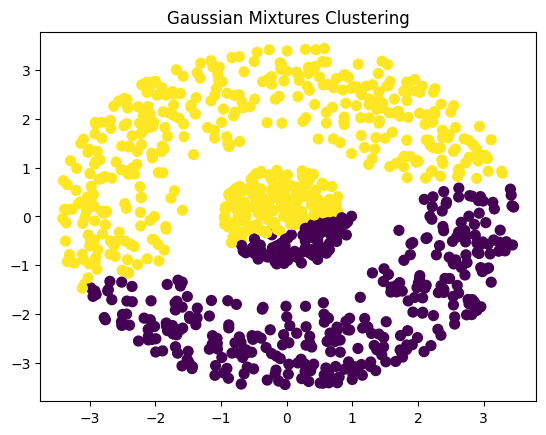

In [ ]:

# КЛАСТЕРИЗАЦИЯ ДЛЯ ПЕРВОГО НАБОРА ПАРАМЕТРОВ
X, y_true = circles, circles_labels

# Метод K-средних
kmeans = KMeans(n_clusters=2, random_state=0, max_iter=1000)
y_kmeans = kmeans.fit_predict(X)

# Метод DBSCAN

dbscan = DBSCAN(eps=0.5, n_jobs=-1, min_samples=2)
y_dbscan = dbscan.fit_predict(X)


# Метод Gaussian Mixture

gmm = GaussianMixture(n_components=2, random_state=0, max_iter=1000)
y_gmm = gmm.fit_predict(X)

# Расчет Rand Index
ri_kmeans = adjusted_rand_score(y_true, y_kmeans)
ri_dbscan = adjusted_rand_score(y_true, y_dbscan)
ri_gmm = adjusted_rand_score(y_true, y_gmm)

def plot_clusters(X, y_pred, title):
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=50, cmap='viridis')
    plt.title(title)
    plt.show()

print(f"Rand Index для K-means: {ri_kmeans}")
plot_clusters(X, y_kmeans, 'K-means Clustering')

print(f"Rand Index для DBSCAN: {ri_dbscan}")
plot_clusters(X, y_dbscan, 'DBSCAN Clustering')

print(f"Rand Index для Gaussian Mixtures: {ri_gmm}")
plot_clusters(X, y_gmm, 'Gaussian Mixtures Clustering')

circles_ri = [ri_kmeans, ri_dbscan, ri_gmm]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Rand Index для K-means: 0.2647828310668119


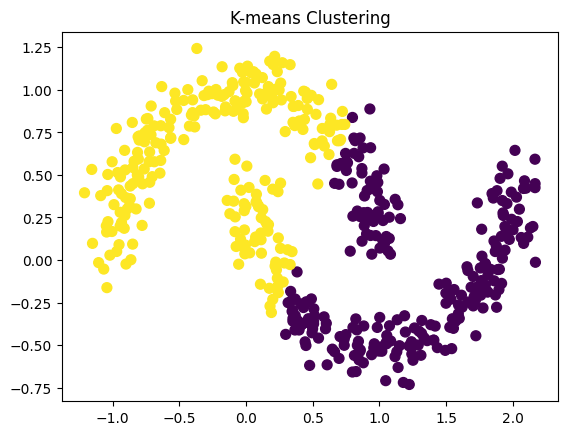

Rand Index для DBSCAN: 1.0


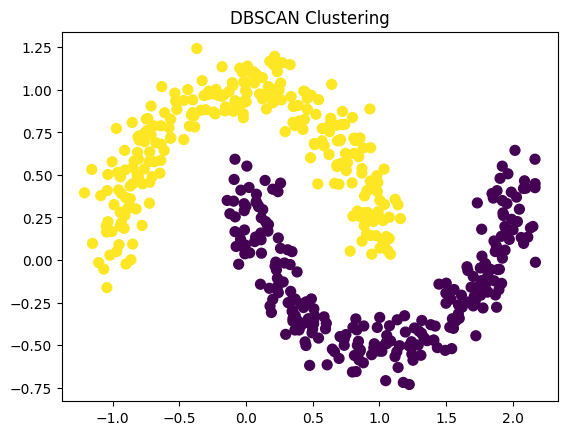

Rand Index для Gaussian Mixtures: 0.45048276305220886


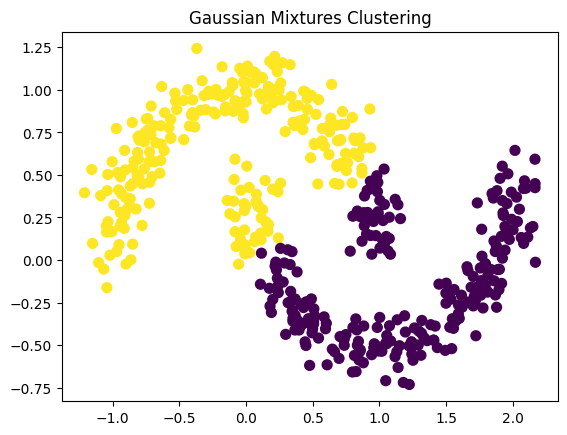

In [ ]:

# КЛАСТЕРИЗАЦИЯ ДЛЯ ВТОРОГО НАБОРА ПАРАМЕТРОВ
X, y_true = moons, moons_labels

# Метод K-средних
kmeans = KMeans(n_clusters=2, random_state=0, max_iter=1000)
y_kmeans = kmeans.fit_predict(X)

# Метод DBSCAN
dbscan = DBSCAN(eps=0.2, n_jobs=-1, min_samples=3)
y_dbscan = dbscan.fit_predict(X)

# Метод Gaussian Mixture
gmm = GaussianMixture(n_components=2, random_state=0, max_iter=1000)
y_gmm = gmm.fit_predict(X)

# Расчет Rand Index
ri_kmeans = adjusted_rand_score(y_true, y_kmeans)
ri_dbscan = adjusted_rand_score(y_true, y_dbscan)
ri_gmm = adjusted_rand_score(y_true, y_gmm)


print(f"Rand Index для K-means: {ri_kmeans}")
plot_clusters(X, y_kmeans, 'K-means Clustering')

print(f"Rand Index для DBSCAN: {ri_dbscan}")
plot_clusters(X, y_dbscan, 'DBSCAN Clustering')

print(f"Rand Index для Gaussian Mixtures: {ri_gmm}")
plot_clusters(X, y_gmm, 'Gaussian Mixtures Clustering')

moons_ri = [ri_kmeans, ri_dbscan, ri_gmm]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Rand Index для K-means: 0.05661377932704073


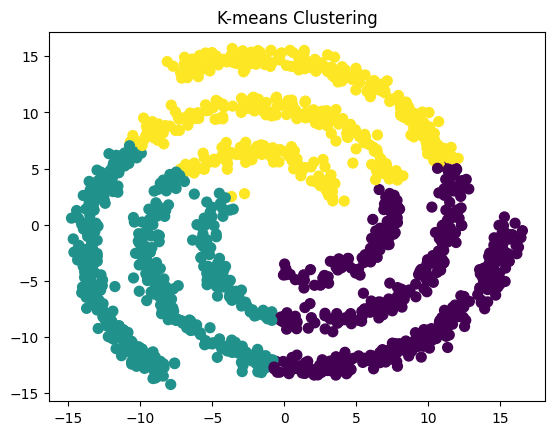

Rand Index для DBSCAN: 0.9979993320004471


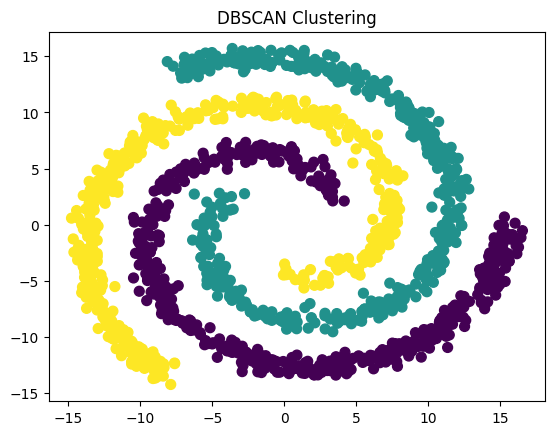

Rand Index для Gaussian Mixtures: 0.10345821064762306


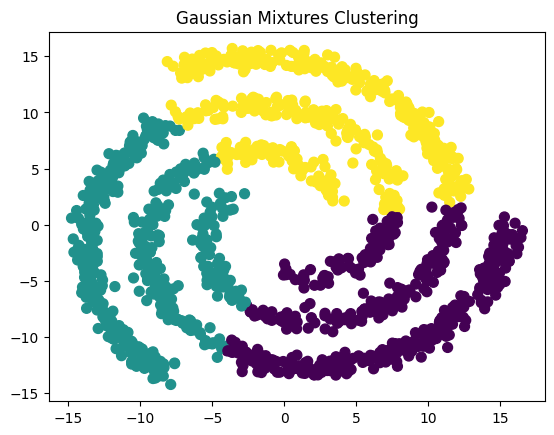

In [ ]:
# КЛАСТЕРИЗАЦИЯ ДЛЯ ТРЕТЬЕГО НАБОРА ПАРАМЕТРОВ
X, y_true = spiral, spiral_labels

# Метод K-средних
kmeans = KMeans(n_clusters=3, random_state=0, max_iter=1000)
y_kmeans = kmeans.fit_predict(X)

# Метод DBSCAN
dbscan = DBSCAN(eps=1.3, n_jobs=-1, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Метод Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=0, max_iter=1000)
y_gmm = gmm.fit_predict(X)

# Расчет Rand Index
ri_kmeans = adjusted_rand_score(y_true, y_kmeans)
ri_dbscan = adjusted_rand_score(y_true, y_dbscan)
ri_gmm = adjusted_rand_score(y_true, y_gmm)


print(f"Rand Index для K-means: {ri_kmeans}")
plot_clusters(X, y_kmeans, 'K-means Clustering')

print(f"Rand Index для DBSCAN: {ri_dbscan}")
plot_clusters(X, y_dbscan, 'DBSCAN Clustering')

print(f"Rand Index для Gaussian Mixtures: {ri_gmm}")
plot_clusters(X, y_gmm, 'Gaussian Mixtures Clustering')

spiral_ri = [ri_kmeans, ri_dbscan, ri_gmm]

In [ ]:
clustering_results = pd.DataFrame({
    'Circles': circles_ri,
    'Moons': moons_ri,
    'Spiral': spiral_ri
})

clustering_results.index = ['K-Means', 'DBSCAN', 'Gaussian Mixtures']
clustering_results

,Circles,Moons,Spiral
K-Means,-0.001144,0.264783,0.056614
DBSCAN,1.000000,1.000000,0.997999
Gaussian Mixtures,-0.000538,0.450483,0.103458


## **Задание 3: Радиально-базисная сеть и автодифференцирование**

**Задание:** Напишите класс RBF, реализующий двуслойную радиально-базисную сеть для классификации этих данных. Помимо основных параметров ширина RBF-функций должна быть также обучаемой переменной. Используйте возможности автодифференцирования pytorch для создания такой модели.

Обучайте такую сеть классификации созданных данных, считайте качество обучения на тестовых данных. Исследуйте влияние числа RBF-нейронов на качество обучения.
Для лучших найденных гиперпараметров отобразите анимацию процесса обучения рисуя поверх графика данных центры и ширины RBF-нейронов. Отображайте текущее качество обучения в подписи графика.

Сохраните анимацию в отдельный видео-файл.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.animation as animation
from IPython.display import HTML

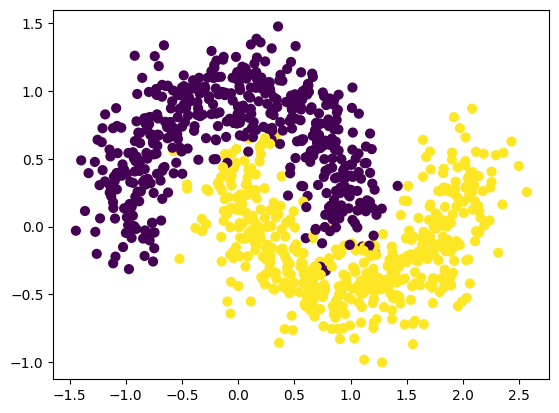

In [ ]:
# Создание данных
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Преобразование данных в тензоры pytorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Отображение данных
plt.scatter(X[:, 0], X[:, 1], c=y, s=40)

In [ ]:
class RBF(nn.Module): # Класс RBFN модели
    def __init__(self, input_dim, num_neurons):
        super(RBF, self).__init__()
        self.num_neurons = num_neurons
        self.centers = nn.Parameter(torch.randn(num_neurons, input_dim))
        self.log_widths = nn.Parameter(torch.zeros(num_neurons))
        self.linear = nn.Linear(num_neurons, 1)

    def rbf_function(self, x, centers, log_widths):
        # Расчет RBF-функций
        widths = torch.exp(log_widths)
        diff = x.unsqueeze(1) - centers.unsqueeze(0)
        dist_sq = torch.sum(diff**2, dim=2)
        return torch.exp(-dist_sq / (2 * widths**2))

    def forward(self, x):
        phi = self.rbf_function(x, self.centers, self.log_widths)
        return torch.sigmoid(self.linear(phi))


In [ ]:
def train_rbf(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_output = model(X_test)
            test_loss = criterion(test_output, y_test)
            test_losses.append(test_loss.item())

        if epoch % 100 == 0 or epoch == 999:
            print(f"Epoch {epoch}, Train Loss: {loss.item()}, Test Loss: {test_loss.item()}")

    return train_losses, test_losses


In [ ]:
neurons = [5, 10, 15, 20, 25, 30, 50]
results = {}
# Подбор лучшего значения нейронов для модели RBFN
for num_neurons in neurons:
    print(f"\nTraining RBF with {num_neurons} neurons:")
    model = RBF(input_dim=2, num_neurons=num_neurons)
    train_losses, test_losses = train_rbf(model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=1000, lr=0.01)
    results[num_neurons] = (train_losses, test_losses)



Training RBF with 5 neurons:
Epoch 0, Train Loss: 0.7403634786605835, Test Loss: 0.7306475639343262
Epoch 100, Train Loss: 0.39640486240386963, Test Loss: 0.3952070474624634
Epoch 200, Train Loss: 0.31873619556427, Test Loss: 0.3191050589084625
Epoch 300, Train Loss: 0.29968681931495667, Test Loss: 0.2980104386806488
Epoch 400, Train Loss: 0.2640379071235657, Test Loss: 0.24847805500030518
Epoch 500, Train Loss: 0.2158527374267578, Test Loss: 0.1905650645494461
Epoch 600, Train Loss: 0.17490313947200775, Test Loss: 0.14866487681865692
Epoch 700, Train Loss: 0.15626227855682373, Test Loss: 0.12768973410129547
Epoch 800, Train Loss: 0.1431138664484024, Test Loss: 0.11290264129638672
Epoch 900, Train Loss: 0.13324837386608124, Test Loss: 0.10186482220888138
Epoch 999, Train Loss: 0.12562566995620728, Test Loss: 0.09339011460542679

Training RBF with 10 neurons:
Epoch 0, Train Loss: 0.6905165910720825, Test Loss: 0.6857422590255737
Epoch 100, Train Loss: 0.309843510389328, Test Loss: 0.30

In [ ]:
def animate_rbf_training(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01, interval=50):
    fig, ax = plt.subplots()
    colors = ['blue' if label == 0 else 'red' for label in y_train]
    ax.scatter(X_train[:, 0], X_train[:, 1], c=colors, s=10)

    centers_scat = ax.scatter([], [], c='green', s=50, edgecolor='k')
    radii_scat = [plt.Circle((0, 0), 0, color='green', fill=False, linestyle='--') for _ in range(model.num_neurons)]
    for circle in radii_scat:
        ax.add_patch(circle)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    def update(frame):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_output = model(X_test)
            test_loss = criterion(test_output, y_test)
            test_losses.append(test_loss.item())

        ax.set_title(f"Epoch {frame}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

        centers = model.centers.detach().numpy()
        widths = torch.exp(model.log_widths).detach().numpy()
        centers_scat.set_offsets(centers)

        artists = [centers_scat]
        for i, circle in enumerate(radii_scat):
            circle.set_center(centers[i])
            circle.set_radius(widths[i])
            artists.append(circle)

        return artists

    anim = animation.FuncAnimation(fig, update, frames=range(epochs), interval=interval, blit=True, repeat=False)
    plt.close(fig)
    return anim

best_num_neurons = 20
best_model = RBF(input_dim=2, num_neurons=best_num_neurons)
anim = animate_rbf_training(best_model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=1000, lr=0.01, interval=50)
anim.save('rbf_training_animation.mp4', writer='ffmpeg') # Сохраниение видео
#  ВРЕМЯ ВЫПОЛНЕНИЯ ~2 МИН 15 СЕК

HTML('<video controls><source src="rbf_training_animation.mp4" type="video/mp4"></video>') # Отображение в колабе (не работает)


# **Блок 3 - Экспертный. Нейросетевые модели анализа данных**

## **Задание 1: Векторные представления изображений.**

**Задание:** Загрузите и распакуйте архив archive.zip с адреса:
https://drive.google.com/uc?id=1ONrKzVseOn8ZjBSK28VCh0bDYDrbun4k


Здесь вы найдете файл full_emoji.csv, содержащий таблицу с названием, номером (из него можно получить путь к файлу), unicode кодом и изображением эмотиконов (несколько для разных компаний). Также в архиве есть сами изображения эмотиконов. Будем работать только с эмотиконами от Google.


Вы должны получить векторные представления для изображений эмотиконов с названиями, указанными ниже. Сравнить их между собой по косинусной похожести.


Вывести на экран сравниваемые эмотиконы (в виде unicode символов, команда print() поддерживает такие символы) и их степень похожести. Похожесть визуально похожих эмотиконов должна получиться существенно больше, чем визуально не похожих.


In [ ]:
!pip install img2vec_pytorch

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [ ]:
import zipfile
import pandas as pd
import os
from PIL import Image
import torch
from img2vec_pytorch import Img2Vec
from torchvision import transforms
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
from time import time
import gdown
URL='https://drive.google.com/uc?id=1ONrKzVseOn8ZjBSK28VCh0bDYDrbun4k'
gdown.download(url=URL)
!unzip archive.zip

Downloading...
From (original): https://drive.google.com/uc?id=1ONrKzVseOn8ZjBSK28VCh0bDYDrbun4k
From (redirected): https://drive.google.com/uc?id=1ONrKzVseOn8ZjBSK28VCh0bDYDrbun4k&confirm=t&uuid=6559fdd8-f1ee-4d13-b735-87989b2a5ffb
To: /content/archive.zip
100%|██████████| 49.9M/49.9M [00:01<00:00, 30.9MB/s]


Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: image/Samsung/1447.png  
  inflating: image/Samsung/1448.png  
  inflating: image/Samsung/1449.png  
  inflating: image/Samsung/145.png   
  inflating: image/Samsung/1450.png  
  inflating: image/Samsung/1451.png  
  inflating: image/Samsung/1452.png  
  inflating: image/Samsung/1453.png  
  inflating: image/Samsung/1454.png  
  inflating: image/Samsung/1455.png  
  inflating: image/Samsung/1456.png  
  inflating: image/Samsung/1457.png  
  inflating: image/Samsung/1458.png  
  inflating: image/Samsung/1459.png  
  inflating: image/Samsung/146.png   
  inflating: image/Samsung/1460.png  
  inflating: image/Samsung/1461.png  
  inflating: image/Samsung/1462.png  
  inflating: image/Samsung/1463.png  
  inflating: image/Samsung/1464.png  
  inflating: image/Samsung/1465.png  
  inflating: image/Samsung/1466.png  
  inflating: image/Samsung/1467.png  
  inflating: image/Samsung/1468.png  
  inflating: image/S

In [ ]:
# Функция для получения векторного представления изображения
def get_image_vector(img_path, img2vec):
    img = Image.open(img_path).convert('RGB')
    return img2vec.get_vec(img, tensor=True)

# Функция для вычисления косинусной похожести
def cosine_similarity_vectors(vec1, vec2):
    return cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]

# Основная функция для сравнения эмотиконов
def compare_emoji(name_list):
    df = pd.read_csv('full_emoji.csv')
    df_filtered = df[df['name'].isin(name_list)]
    img2vec = Img2Vec(cuda=torch.cuda.is_available())
    vectors = {}

    # Получение векторных представлений для эмотиконов
    for _, row in df_filtered.iterrows():
        img_path = os.path.join('image/Google', f"{row['#']}.png")
        vec = get_image_vector(img_path, img2vec)
        vectors[row['name']] = vec

    # Сравнение эмотиконов
    for i in range(len(name_list)):
        for j in range(i + 1, len(name_list)):
            name1, name2 = name_list[i], name_list[j]
            vec1, vec2 = vectors[name1], vectors[name2]
            similarity = cosine_similarity_vectors(vec1, vec2)
            print(f"Похожесть {df_filtered[df_filtered['name'] == name1]['emoji'].values[0]} и {df_filtered[df_filtered['name'] == name2]['emoji'].values[0]} --> {similarity:.4f}")




In [ ]:
name_list = ['grinning face', 'beaming face with smiling eyes', 'flag: Scotland']
compare_emoji(name_list)

Похожесть 😀 и 😁 --> 0.8933
Похожесть 😀 и 🏴󠁧󠁢󠁳󠁣󠁴󠁿 --> 0.5992
Похожесть 😁 и 🏴󠁧󠁢󠁳󠁣󠁴󠁿 --> 0.6007


## **Задание 2: Векторные представления слов.**

**Задание:** Загрузите корпус текстов, содержащих предложения как со словами, так и эмотиконами по адресу:
https://drive.google.com/u/1/uc?id=1TPaQTYDpf7p2EklUkLdjK9T5ATztj7oF&export=download

Выведите несколько предложений на экран, убедитесь, что эмотиконы отображаются корректно. Кодировка текста - utf-8.
Разделите предложения по словам, считая эмотикон отдельным словом (нужно подобрать правильный символ-разделитель). В корпусе ровно 1000000 строк.

Эмотиконы представлены в виде символов UNICODE с определенными кодами. Сделайте функцию is_emoji(word), которая позволяет проверить, является ли символ или слово эмотиконом (по коду). Такую функцию можно найти в репозитарии или написать самому.

Средствами библиотеки gensim создайте и обучите Word2Vec модель на этом наборе слов и словарь всех "слов". Размер векторных представлений - 300, прочие аргументы выбирайте самостоятельно, с учетом последующих требований. Ограничьте время обучения, чтобы оно не превосходило 5 минут. Время обучения выведите на экран.

Отберите из словаря только эмотиконы. Они являются символами Unicode. Создайте и выведите на экран таблицу pandas со столбцами, содержащими эмотиконы и их коды. Код для символа можно получить командой ord(). Какой размер таблицы?
Проверьте, что в словаре помимо эмотиконов есть и обычные слова, выведите на экран 10 первых слов из словаря.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
import re
import time
from gensim.models import Word2Vec
import pandas as pd


In [ ]:
import os
import gdown
URL='https://drive.google.com/u/1/uc?id=1TPaQTYDpf7p2EklUkLdjK9T5ATztj7oF&export=download'
gdown.download(url=URL)
!unzip corpus.zip

Downloading...
From: https://drive.google.com/u/1/uc?id=1TPaQTYDpf7p2EklUkLdjK9T5ATztj7oF&export=download
To: /content/corpus.zip
100%|██████████| 22.0M/22.0M [00:02<00:00, 9.42MB/s]


Archive:  corpus.zip
  inflating: corpus.txt              


In [ ]:
# Функция для проверки эмотиконов
def is_emoji(word):
    return any('\U0001F600' <= char <= '\U0001F64F' or
               '\U0001F300' <= char <= '\U0001F5FF' or
               '\U0001F680' <= char <= '\U0001F6FF' or
               '\U0001F700' <= char <= '\U0001F77F' or
               '\U0001F780' <= char <= '\U0001F7FF' or
               '\U0001F800' <= char <= '\U0001F8FF' or
               '\U0001F900' <= char <= '\U0001F9FF' or
               '\U0001FA00' <= char <= '\U0001FA6F' or
               '\U0001FA70' <= char <= '\U0001FAFF' or
               '\U00002702' <= char <= '\U000027B0' or
               '\U000024C2' <= char <= '\U0001F251'
               for char in word)

# Функция для чтения и предобработки корпуса
def preprocess_corpus(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    sentences = []
    for line in lines:
        words = re.split(r'\s+', line.strip())
        sentences.append(words)

    return sentences

file_path = 'corpus.txt'
sentences = preprocess_corpus(file_path)



In [ ]:
# Создание и обучение модели Word2Vec
start_time = time.time()
model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)
end_time = time.time()
train_time = end_time - start_time

print(f"Время обучения: {train_time} секунд")


Время обучения: 119.62305355072021 секунд


In [ ]:
# Извлечение эмотиконов и их кодов
emoji_dict = {word: [ord(char) for char in word] for word in model.wv.index_to_key if is_emoji(word)}

# Создание таблицы с эмотиконами и их кодами
emoji_df = pd.DataFrame([(word, codes) for word, codes in emoji_dict.items()], columns=['Emoji', 'Unicode'])

vocabulary = list(model.wv.index_to_key)
print(f"Первые 10 слов в словаре: {vocabulary[:10]}")
print(f"Размер таблицы с эмотиконами: {emoji_df.shape}")
emoji_df.head()

Первые 10 слов в словаре: ['i', 'the', 'to', 'you', 'a', '😂', 'my', 'and', 'me', 'for']
Размер таблицы с эмотиконами: (2031, 2)


,Emoji,Unicode
0,😂,[128514]
1,😭,[128557]
2,😍,[128525]
3,️,[65039]
4,😊,[128522]


**1) Похожесть эмотиконов.**

Посчитайте и выведите на экран 10 наиболее похожих токенов на эмотикон 😊. Сколько среди них слов, сколько эмотиконов?

Чек-поинт 1: Модель должна быть обучена так, чтобы среди похожих токенов эмотиконов было не менее 5.


In [ ]:
# Найти 10 наиболее похожих токенов на эмотикон 😊
similar_tokens = model.wv.most_similar('😊', topn=10)
similar_words = [token for token, _ in similar_tokens if not is_emoji(token)]
similar_emojis = [token for token, _ in similar_tokens if is_emoji(token)]

print("10 наиболее похожих токенов на эмотикон 😊:")
for token, similarity in similar_tokens:
    print(f"{token}: {similarity}")

print(f"\nКоличество слов: {len(similar_words)}")
print(f"Количество эмотиконов: {len(similar_emojis)}")

10 наиболее похожих токенов на эмотикон 😊:
😉: 0.63849276304245
🙂: 0.6299951672554016
😀: 0.6081501245498657
😌: 0.5909685492515564
😄: 0.5788270831108093
😃: 0.5521389245986938
😇: 0.5509946942329407
😁: 0.5387232899665833
🙃: 0.4973568022251129
and: 0.4906349182128906

Количество слов: 1
Количество эмотиконов: 9


**2) Похожесть слов на эмотиконы.**

Посчитайте и выведите на экран 10 наиболее похожих токенов на слово cat. Сколько среди них слов, сколько эмотиконов?

Чек-поинт 2: Модель должна быть обучена так, чтобы среди похожих токенов был хотя бы 1 эмотикон.

Среди похожих токенов из п.2 есть хотя бы 1 эмотикон. Найдите его, для него выведите на экран 5 самых близких токенов. Какой токен оказался самым близким к этому эмотикону, это слово или эмотикон?


In [ ]:
similar_tokens_cat = model.wv.most_similar('cat', topn=10)
similar_words_cat = [token for token, _ in similar_tokens_cat if not is_emoji(token)]
similar_emojis_cat = [token for token, _ in similar_tokens_cat if is_emoji(token)]

print("10 наиболее похожих токенов на слово 'cat':")
for token, similarity in similar_tokens_cat:
    print(f"{token}: {similarity}")

print(f"\nКоличество слов: {len(similar_words_cat)}")
print(f"Количество эмотиконов: {len(similar_emojis_cat)}\n")


similar_tokens_cat_emoji = model.wv.most_similar(similar_emojis_cat[0], topn=5)
similar_words_cat_emoji = [token for token, _ in similar_tokens_cat_emoji if not is_emoji(token)]
similar_emojis_cat_emoji = [token for token, _ in similar_tokens_cat_emoji if is_emoji(token)]

print(f"5 наиболее похожих токенов на '{similar_emojis_cat[0]}':")
for token, similarity in similar_tokens_cat_emoji:
    print(f"{token}: {similarity}")

10 наиболее похожих токенов на слово 'cat':
dog: 0.7575443387031555
kitten: 0.6640806198120117
puppy: 0.645494282245636
🐱: 0.6347382664680481
pup: 0.6104207038879395
tiny: 0.6028496623039246
kitty: 0.6004958152770996
pet: 0.5716091394424438
cats: 0.5573223829269409
blanket: 0.5550395846366882

Количество слов: 9
Количество эмотиконов: 1

5 наиболее похожих токенов на '🐱':
pussy: 0.6456880569458008
cat: 0.6347382068634033
kitty: 0.6014494299888611
🐈: 0.5989879369735718
🍆: 0.5867421627044678


**3) Отношения эмотиконов и слов.**

А) Найти ближайшее слово X подходящее под уравнение: 🐱 - 🐶 = cat - X

In [ ]:
wv = model.wv
tokenA='🐱'
tokenB='🐶'
tokenC='cat'

out = wv[tokenC]-wv[tokenA]+wv[tokenB]
candidate = [x for x in wv.similar_by_vector(out,topn=50) if x[0] not in [tokenA,tokenB,tokenC]]

res = [x for x in candidate if not is_emoji(x[0])][0]

print(f"🐱 - 🐶 = cat - X\nX = {res[0]}")
print(f"Уровень похожести: {res[1]}")

🐱 - 🐶 = cat - X
X = puppy
Уровень похожести: 0.6753081679344177


Б) Найдите ближайший эмотикон Х подходящий под уравнение:
cat - dog = 🐱 - X


In [ ]:
tokenA='cat'
tokenB='dog'
tokenC='🐱'

out = wv[tokenC] - wv[tokenA] + wv[tokenB]
candidate = [x for x in wv.similar_by_vector(out,topn=50) if x[0] not in [tokenA,tokenB,tokenC]]
res = [x for x in candidate if is_emoji(x[0])][0]

print(f"cat - dog = 🐱 - X\nX = {res[0]}")
print(f"Уровень похожести: {res[1]}")

cat - dog = 🐱 - X
X = 🐶
Уровень похожести: 0.5843919515609741


**4) Проекции векторов эмотиконов на плоскость.**

Возьмите вектора эмотиконов. Переведите эти вектора на плоскость, пользуясь методами PCA и TSNE.

Нарисуйте на плоскости миниатюры изображений эмотиконов, координаты этих изображений определяются полученными кооординатами векторов на плоскости.


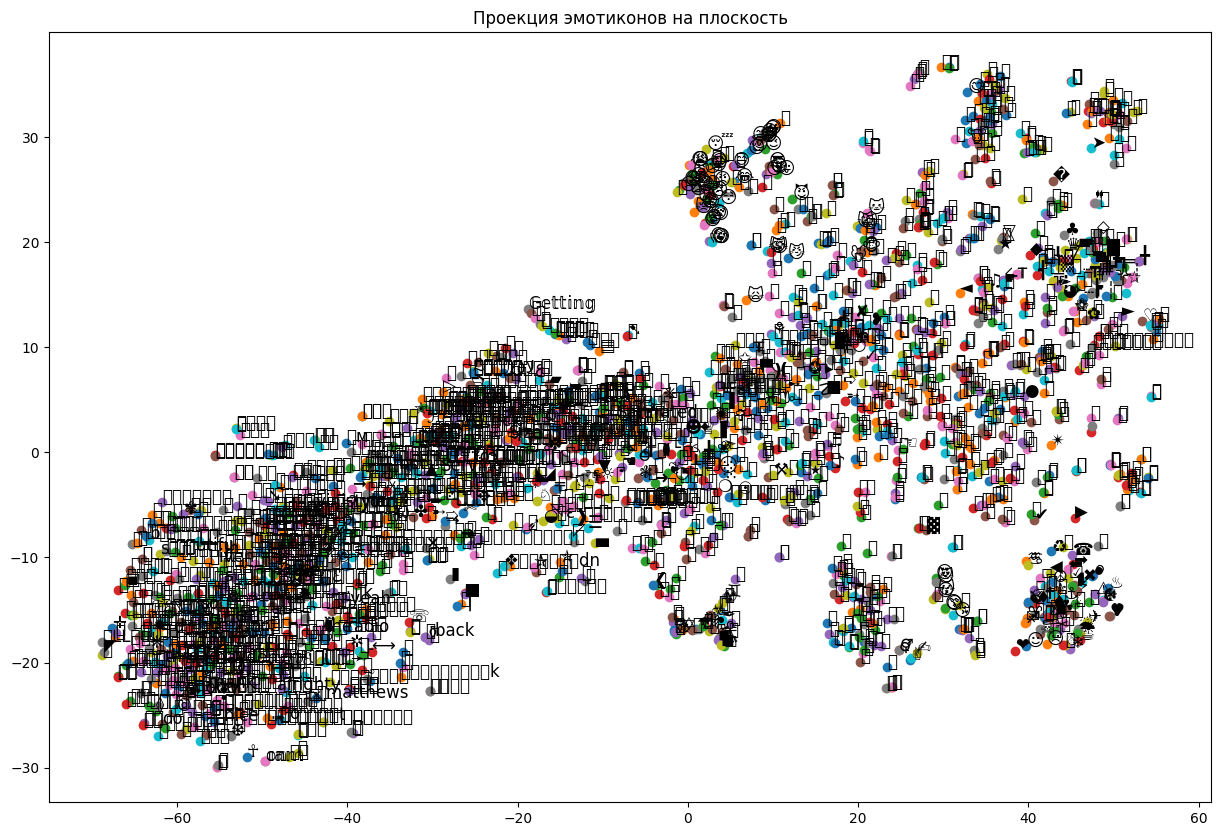

In [ ]:
warnings.filterwarnings('ignore')

# Извлечение векторов эмотиконов из модели
emoji_vectors = [model.wv[word] for word in emoji_df['Emoji']]
emoji_labels = emoji_df['Emoji']

# Применение PCA для уменьшения размерности до 50
pca = PCA(n_components=50)
emoji_vectors_pca = pca.fit_transform(emoji_vectors)

# Применение TSNE для уменьшения размерности до 2
tsne = TSNE(n_components=2)
emoji_vectors_tsne = tsne.fit_transform(emoji_vectors_pca)

plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(emoji_vectors_tsne):
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, emoji_labels[i], fontsize=12)

plt.title("Проекция эмотиконов на плоскость")
plt.show()